# 01 — EDA and Baseline

This notebook builds a first clean baseline for the Kaggle **House Prices — Advanced Regression Techniques** competition.

The goal is not to maximize leaderboard score immediately. The goal is to create a readable, reproducible workflow: load data, inspect it, preprocess features, validate baseline models, and generate a correct submission file.

## 1. Introduction

Kaggle evaluates this competition with RMSE on the logarithm of house prices. Therefore, the reusable pipeline trains on `log1p(SalePrice)` and converts final predictions back with `expm1`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make the project package importable when this notebook is run from the notebooks folder.
PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path("projects/kaggle-house-prices").resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.config import SUBMISSION_PATH
from src.data import load_train_test
from src.features import prepare_features
from src.model import fit_best_model, train_baseline_models

## 2. Loading the data

Place `train.csv`, `test.csv`, and `sample_submission.csv` in `projects/kaggle-house-prices/data/raw/` before running this notebook.

In [2]:
train_df, test_df = load_train_test()
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. Train/test dimensions

A quick shape check confirms the number of rows and columns available for training and prediction.

In [3]:
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (1460, 81)
Test shape:  (1459, 80)


## 4. Quick SalePrice analysis

The target is right-skewed, which is why the log transformation is useful for this competition.

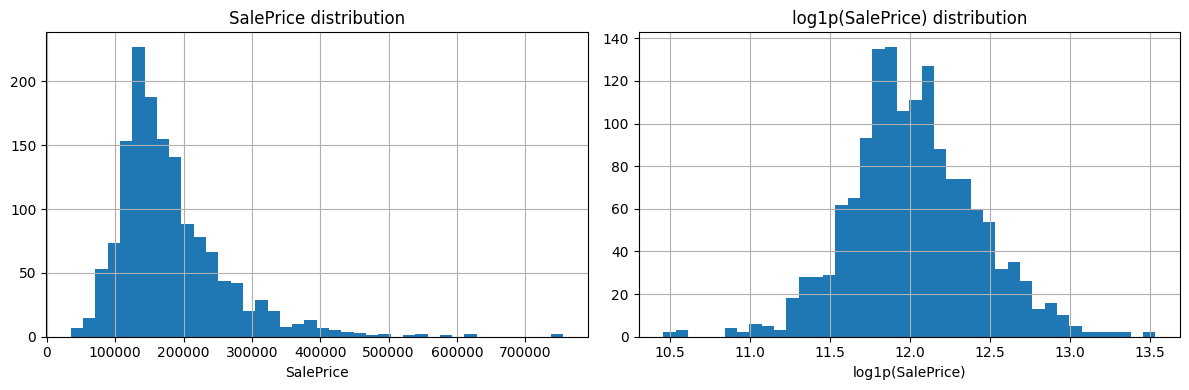

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["SalePrice"].hist(bins=40, ax=axes[0])
axes[0].set_title("SalePrice distribution")
axes[0].set_xlabel("SalePrice")

np.log1p(train_df["SalePrice"]).hist(bins=40, ax=axes[1])
axes[1].set_title("log1p(SalePrice) distribution")
axes[1].set_xlabel("log1p(SalePrice)")
plt.tight_layout()

## 5. Main missing values

Missing values are common in the Ames dataset. Some indicate absence of a feature, while others are true missing measurements. The first baseline uses generic imputation; later iterations should use the data dictionary.

In [5]:
missing = train_df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 6. Numeric and categorical variables

The baseline separates columns by dtype: numeric columns get median imputation, categorical columns get a `Missing` level.

In [6]:
numeric_cols = train_df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = train_df.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print("Example categorical columns:", categorical_cols[:10])

Numeric columns: 38
Categorical columns: 43
Example categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


## 7. Top correlations with SalePrice

Correlation is only a linear signal, but it quickly highlights important numeric variables such as overall quality and living area.

In [7]:
corr = train_df.select_dtypes(include=["number"]).corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

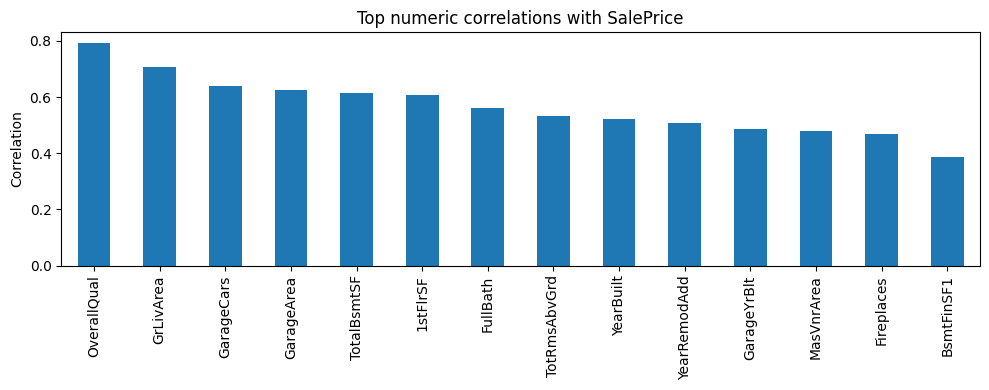

In [8]:
corr.head(15).drop("SalePrice").plot(kind="bar", figsize=(10, 4), title="Top numeric correlations with SalePrice")
plt.ylabel("Correlation")
plt.tight_layout()

## 8. Preprocessing

The reusable preprocessing function returns aligned matrices and the log-transformed target.

In [9]:
X_train, X_test, y = prepare_features(train_df, test_df)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Target shape:  {y.shape}")
assert list(X_train.columns) == list(X_test.columns)

X_train shape: (1460, 310)
X_test shape:  (1459, 310)
Target shape:  (1460,)


## 9. Baseline model comparison

Evaluate the candidate models once, store their cross-validation scores, and reuse those scores for model selection.


In [10]:
scores = train_baseline_models(X_train, y)
scores


,model,cv_rmse_log
0,random_forest,0.14494
1,ridge,0.14915


## 10. Ridge score

Ridge regression is a strong baseline for one-hot encoded tabular data because regularization helps control overfitting.


In [11]:
ridge_score = scores.loc[scores["model"] == "ridge", "cv_rmse_log"].iloc[0]
print(f"Ridge CV RMSE on log target: {ridge_score:.5f}")


Ridge CV RMSE on log target: 0.14915


## 11. RandomForest score

RandomForest is included as a simple nonlinear comparison. It is slower than Ridge but still reasonable for this dataset.


In [12]:
rf_score = scores.loc[scores["model"] == "random_forest", "cv_rmse_log"].iloc[0]
print(f"RandomForest CV RMSE on log target: {rf_score:.5f}")


RandomForest CV RMSE on log target: 0.14494


## 12. Generate `submission.csv`

The predictions are produced on the log scale and converted back to prices with `expm1`. The output file has the Kaggle-required columns `Id` and `SalePrice`.

In [13]:
best_model = fit_best_model(X_train, y, scores=scores)
predictions = np.expm1(best_model.predict(X_test))
predictions = np.maximum(predictions, 1e-9)

submission = pd.DataFrame({
    "Id": test_df["Id"].values,
    "SalePrice": predictions,
})

assert list(submission.columns) == ["Id", "SalePrice"]
assert len(submission) == len(test_df)
assert not submission["SalePrice"].isna().any()
assert (submission["SalePrice"] > 0).all()

SUBMISSION_PATH.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(SUBMISSION_PATH, index=False)
submission.head()

,Id,SalePrice
0,1461,125147.779063
1,1462,154798.018274
2,1463,179654.523092
3,1464,180166.489724
4,1465,194548.975928


In [14]:
print(f"Submission saved to: {SUBMISSION_PATH}")
print(submission.columns.tolist())
print(submission.shape)

Submission saved to: /workspace/House-Prices-Advanced-Regression-Techniques/projects/kaggle-house-prices/data/submissions/submission_baseline.csv
['Id', 'SalePrice']
(1459, 2)


## 13. Model limitations

- Missing values are imputed generically instead of using domain-specific meaning.
- Skewed numeric features are not transformed yet.
- Feature engineering is minimal.
- Hyperparameters are not tuned.
- No interpretability analysis is included in this first version.

## 14. Next improvements

- Add total surface features.
- Use the Kaggle data dictionary to handle meaningful missing values.
- Log-transform highly skewed numeric features.
- Tune regularized linear models: Ridge, Lasso, ElasticNet.
- Try simple stacking.
- Add permutation importance or SHAP analysis.